In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Imputacja
from sklearn.impute import SimpleImputer, KNNImputer

# Skalowanie
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Outlier detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Klasyfikator bazowy do oceny
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    classification_report,
)

print("Biblioteki załadowane.")

Biblioteki załadowane.


In [149]:
from ucimlrepo import fetch_ucirepo

polish_companies_bankruptcy = fetch_ucirepo(id=365)

X = polish_companies_bankruptcy.data.features
y = polish_companies_bankruptcy.data.targets

- check number of companies in each year

In [150]:
X.head()

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A55,A56,A57,A58,A59,A60,A61,A62,A63,A64
0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,...,348690.0,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277
1,1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,...,2304.6,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870
2,1,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,...,6332.7,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078
3,1,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,...,20545.0,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497
4,1,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,...,3186.6,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980


In [151]:
y.head()

,class
0,0
1,0
2,0
3,0
4,0


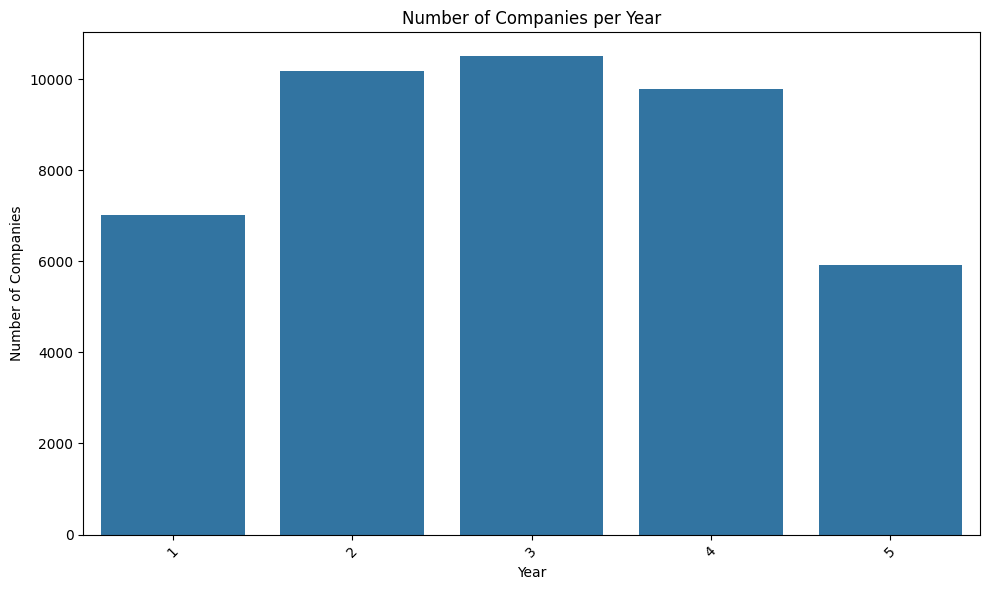

In [152]:
years = X["year"].unique()
counts = X["year"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=years, y=counts.values)
plt.title("Number of Companies per Year")
plt.xlabel("Year")
plt.ylabel("Number of Companies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- filter data for 3 only

In [153]:
mask_2010 = X["year"] == 3

X = X[mask_2010].drop(columns=["year"])
y = y[mask_2010]

In [154]:
X["class"] = y

In [155]:
X.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
count,10503.000000,10503.000000,10503.000000,10485.000000,1.047800e+04,10503.000000,10503.000000,10489.000000,10500.000000,10503.000000,...,10460.000000,10503.000000,10474.000000,10503.000000,9.911000e+03,10486.000000,1.046000e+04,10485.000000,10275.000000,10503.000000
mean,0.052844,0.619911,0.095490,9.980499,-1.347355e+03,-0.121159,0.065624,19.140113,1.819254,0.366093,...,-0.530082,-0.014817,3.848794,1.429319,5.713958e+02,13.935361,1.348668e+02,9.095149,35.766800,0.047129
std,0.647797,6.427041,6.420056,523.691951,1.185517e+05,6.970625,0.651152,717.756745,7.581659,6.428603,...,55.978608,18.684047,190.201224,77.273270,3.715816e+04,83.704103,2.600764e+04,31.419096,428.298315,0.211926
min,-17.692000,0.000000,-479.730000,0.002080,-1.190000e+07,-508.120000,-17.692000,-2.081800,-1.215700,-479.730000,...,-5691.700000,-1667.300000,-198.690000,-172.070000,0.000000e+00,-6.590300,-2.340000e+06,-0.000156,-0.000102,0.000000
25%,0.000686,0.253955,0.017461,1.040100,-5.207075e+01,0.000000,0.002118,0.431270,1.011275,0.297340,...,0.005137,0.006796,0.875560,0.000000,5.533150e+00,4.486075,4.073700e+01,3.062800,2.023350,0.000000
50%,0.043034,0.464140,0.198560,1.605600,1.579300e+00,0.000000,0.050945,1.111000,1.199000,0.515500,...,0.051765,0.106880,0.953060,0.002976,9.952100e+00,6.677300,7.066400e+01,5.139200,4.059300,0.000000
75%,0.123805,0.689330,0.419545,2.959500,5.608400e+01,0.072584,0.142275,2.857100,2.059100,0.725635,...,0.130010,0.271310,0.995927,0.240320,2.093600e+01,10.587500,1.182200e+02,8.882600,9.682750,0.000000
max,52.652000,480.730000,17.708000,53433.000000,6.850000e+05,45.533000,52.652000,53432.000000,740.440000,11.837000,...,293.150000,552.640000,18118.000000,7617.300000,3.660000e+06,4470.400000,1.070000e+06,1974.500000,21499.000000,1.000000


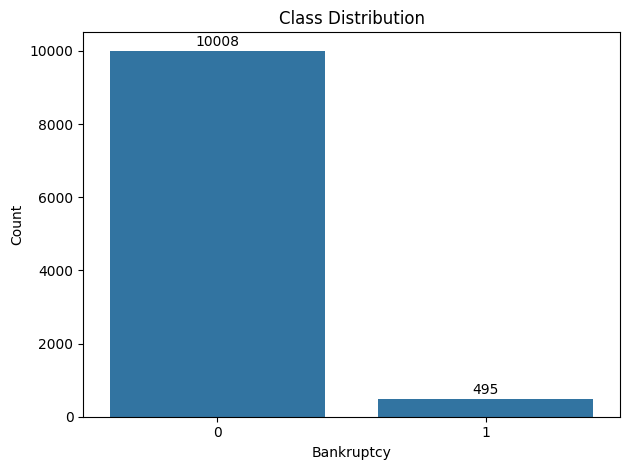

In [156]:
sns.countplot(data=y, x="class")
plt.title("Class Distribution")
plt.xlabel("Bankruptcy")
plt.ylabel("Count")
ax = plt.gca()
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 1),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

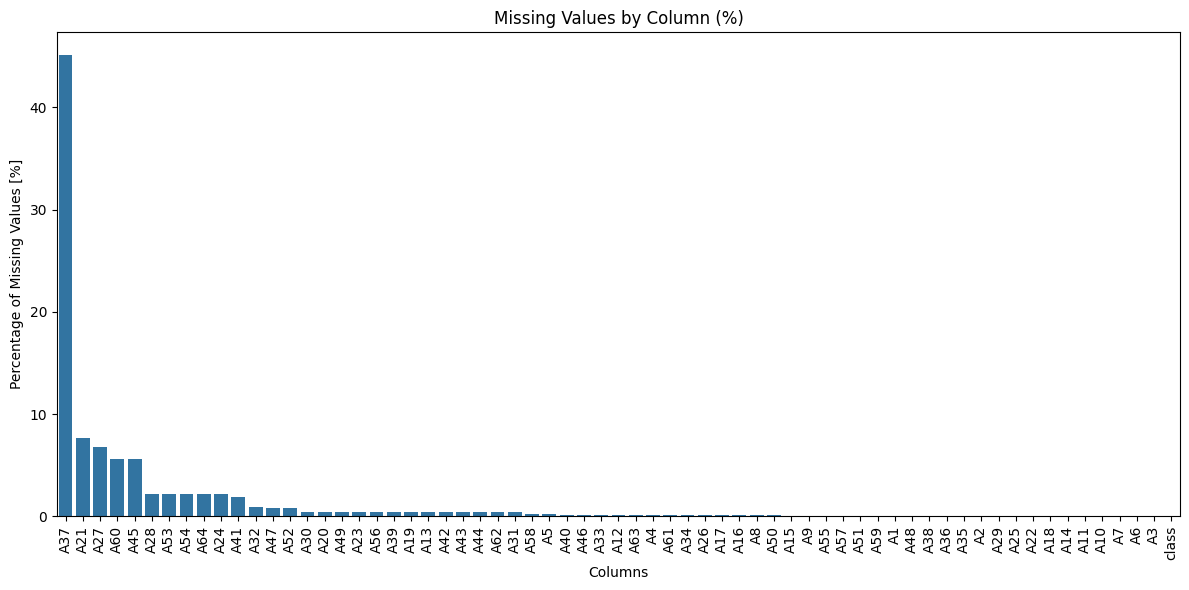

In [157]:
missing_values = X.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_values / len(X)) * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=missing_pct.index, y=missing_pct.values)
plt.xticks(rotation=90)
plt.title("Missing Values by Column (%)")
plt.xlabel("Columns")
plt.ylabel("Percentage of Missing Values [%]")
plt.tight_layout()
plt.show()

In [158]:
X = X.drop(columns=["A37"])

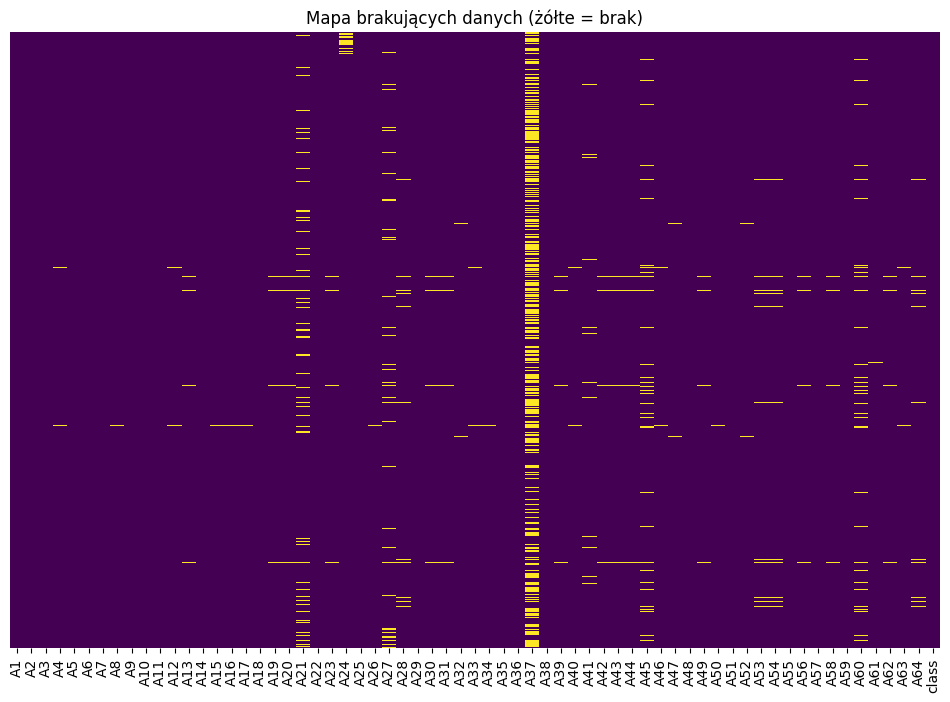

In [130]:
plt.figure(figsize=(12, 8))
sns.heatmap(X.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Mapa brakujących danych (żółte = brak)")
plt.show()

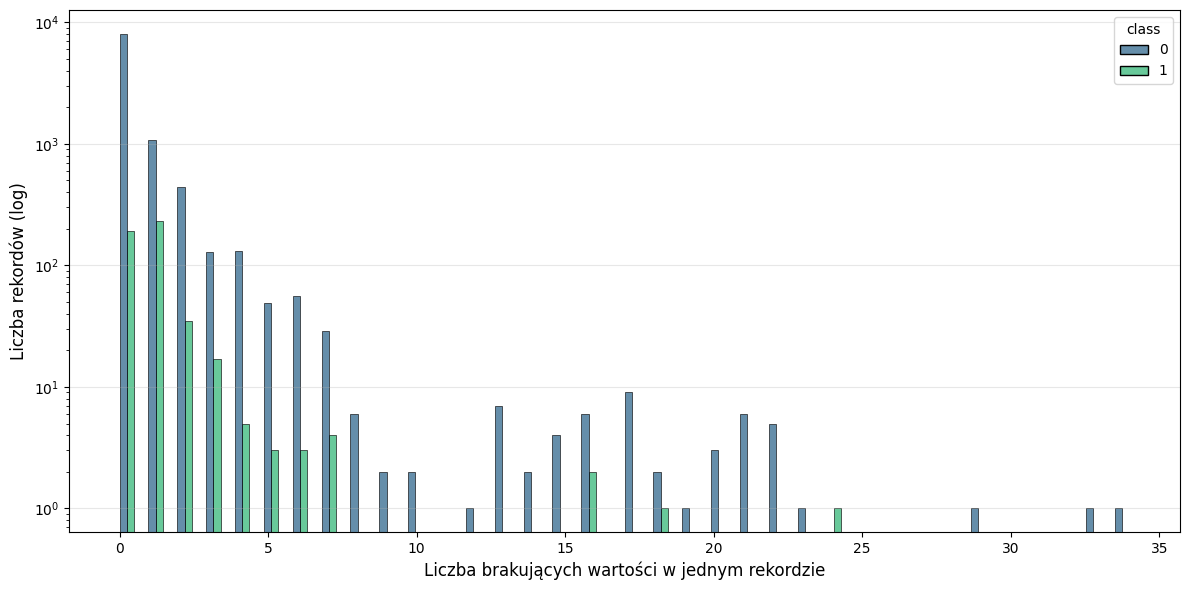

In [160]:
X["missing_count"] = X.drop(columns=["class"]).isnull().sum(axis=1)

plt.figure(figsize=(12, 6))

sns.histplot(
    data=X,
    x="missing_count",
    hue="class",
    bins=70,
    kde=False,
    palette="viridis",
    multiple="dodge",
)

plt.xlabel("Liczba brakujących wartości w jednym rekordzie", fontsize=12)
plt.ylabel("Liczba rekordów (log)", fontsize=12)

plt.yscale("log")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

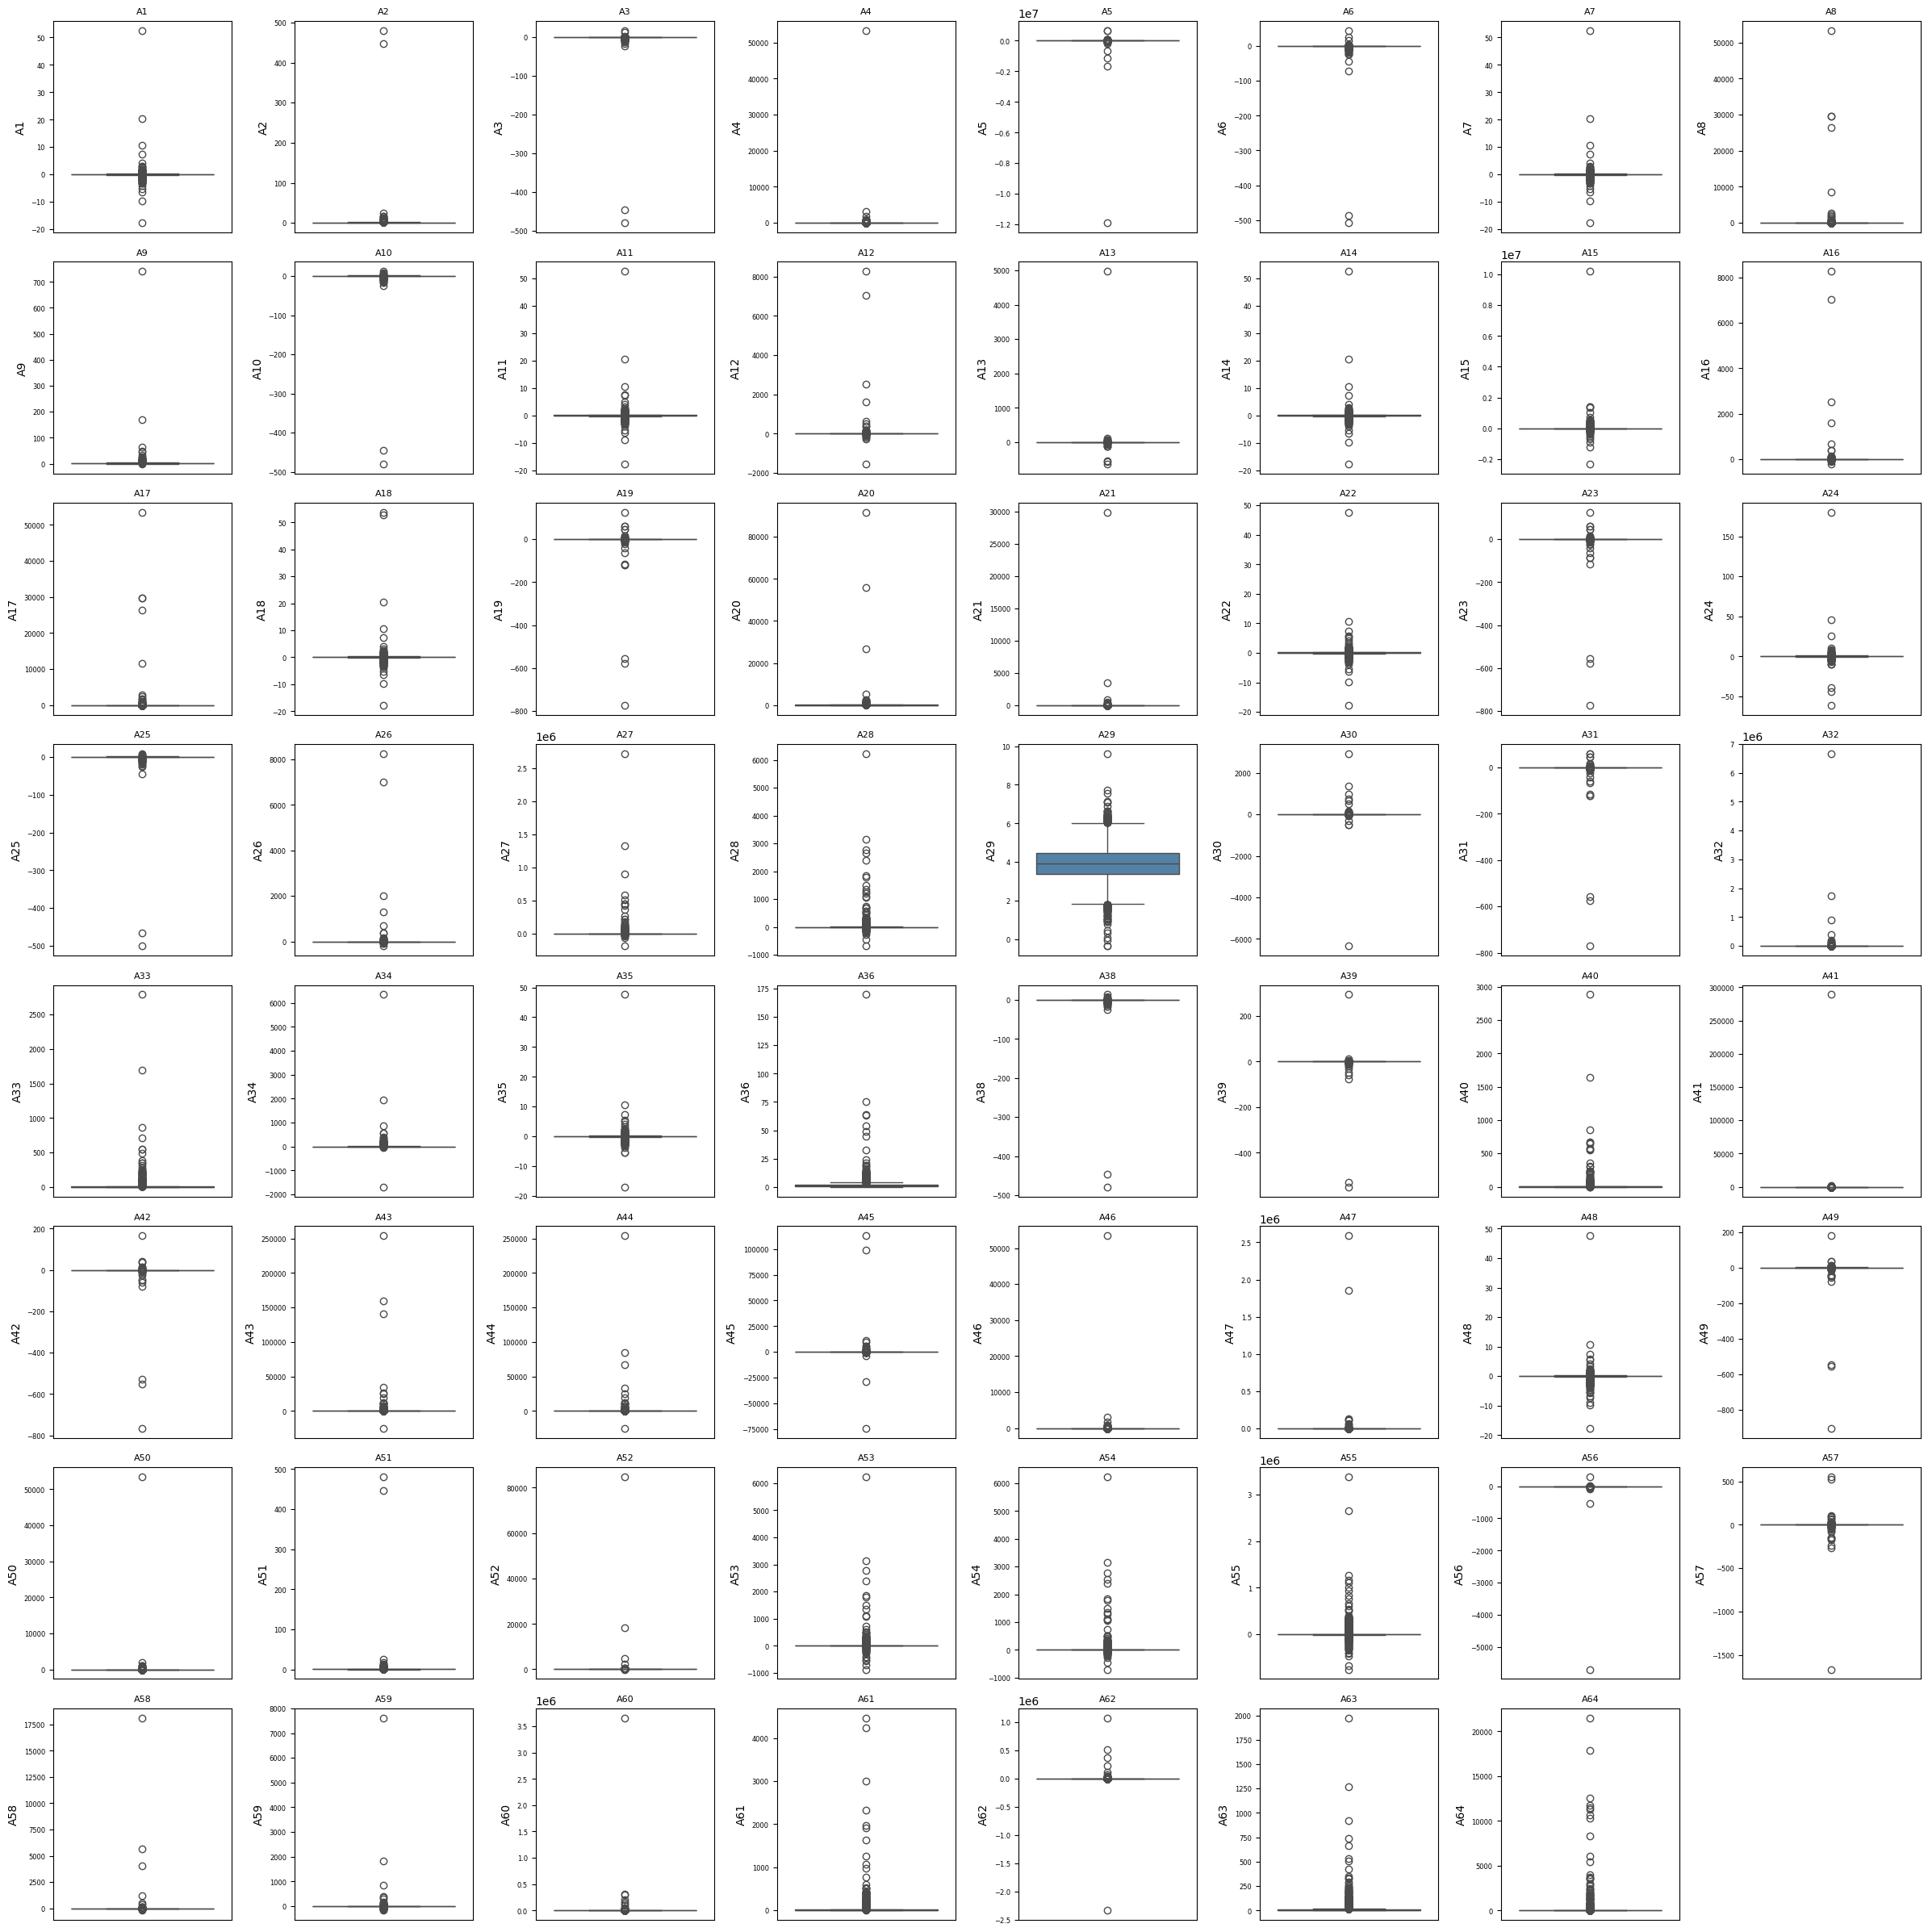

In [ ]:
cols = X.columns
n_cols = 8
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(n_cols * 3, n_rows * 3))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=X[col], color="steelblue")
    plt.title(col, fontsize=8)
    plt.xticks([])
    plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()

___

In [169]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.pipeline import Pipeline

In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    X.drop(columns=["class"]),
    X["class"],
    test_size=0.2,
    stratify=X["class"],
    random_state=42,
)

In [173]:
proportion_train = y_train.value_counts(normalize=True).sort_index()
proportion_test = y_test.value_counts(normalize=True).sort_index()

comparison = pd.concat(
    [proportion_train.rename("train"), proportion_test.rename("test")], axis=1
).fillna(0)

comparison["diff_pp"] = (comparison["train"] - comparison["test"]) * 100

print("Porównanie proporcji klas")
print((comparison * 100).round(2))

max_diff = comparison["diff_pp"].abs().max()

Porównanie proporcji klas
       train   test  diff_pp
class                       
0      95.29  95.29    -0.11
1       4.71   4.71     0.11


___

In [2]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.nanpercentile(X, 25, axis=0)
        Q3 = np.nanpercentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.k * IQR
        self.upper_ = Q3 + self.k * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)


class PassthroughTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return np.array(X, dtype=float)

In [5]:
IMPUTERS = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "knn": KNNImputer(n_neighbors=5),
}

OUTLIERS = {"none": PassthroughTransformer(), "IQR_clip": IQRClipper(k=1.5)}

SCALERS = {
    "none": PassthroughTransformer(),
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}

MODELS = {
    "logistic_regression": LogisticRegression(random_state=42),
    "decision_tree": DecisionTreeClassifier(random_state=42),
}

In [9]:
from itertools import product
import copy
from tqdm import tqdm

In [15]:
# Ensure split exists even if this cell is run independently.
if not all(name in globals() for name in ["X_train", "X_test", "y_train", "y_test"]):
    X_train, X_test, y_train, y_test = train_test_split(
        X.drop(columns=["class"]),
        X["class"],
        test_size=0.2,
        stratify=X["class"],
        random_state=42,
    )

results = []
transformed_data = {}
total = len(IMPUTERS) * len(OUTLIERS) * len(SCALERS) * len(MODELS)
i = 0

for imp_name, out_name, scale_name, model_name in tqdm(
    product(IMPUTERS.keys(), OUTLIERS.keys(), SCALERS.keys(), MODELS.keys()),
    total=total,
):
    label = f"{imp_name} | {out_name} | {scale_name} | {model_name}"
    i += 1

    preprocess = Pipeline(
        [
            ("imputer", copy.deepcopy(IMPUTERS[imp_name])),
            ("outlier", copy.deepcopy(OUTLIERS[out_name])),
            ("scaler", copy.deepcopy(SCALERS[scale_name])),
        ]
    )

    X_tr = preprocess.fit_transform(X_train, y_train)
    X_te = preprocess.transform(X_test)

    transformed_data[label] = (X_tr, X_te)
    model = copy.deepcopy(MODELS[model_name])
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    row = {
        "label": label,
        "imputer": imp_name,
        "outlier": out_name,
        "scaler": scale_name,
        "model": model_name,
        "accuracy_score": accuracy_score(y_test, y_pred),
        "precision_score": precision_score(y_test, y_pred, zero_division=0),
        "recall_score": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc_score": roc_auc_score(y_test, y_prob),
        "conf_matrix": classification_report(y_test, y_pred, output_dict=True),
        "X_train_transformed": X_tr,
        "X_test_transformed": X_te,
    }
    results.append(row)

NameError: name 'X' is not defined

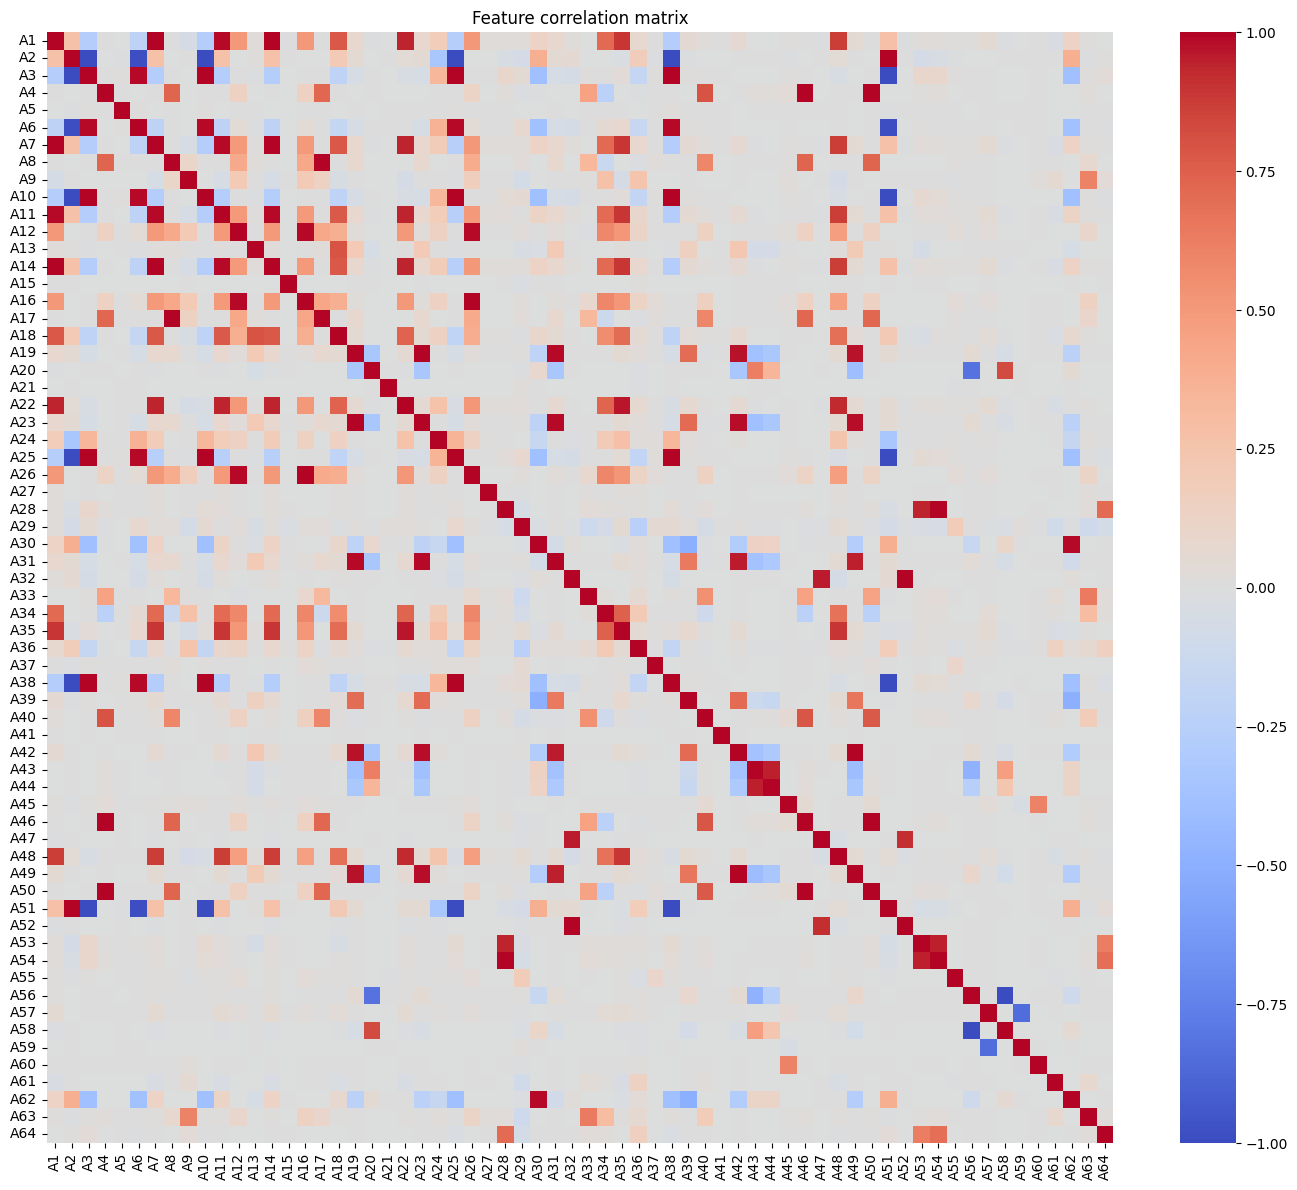

In [84]:
corr = X.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=True,
    yticklabels=True,
    linewidths=0,
)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()